In [2]:
from mrc import DVFile
from tifffile import imwrite, imread
from skimage.filters import laplace

import numpy as np
import pandas as pd

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ConfIntSampler

from matplotlib import pyplot as plt
import seaborn as sns

from cellpose_omni import models, core, io, transforms
import cellpose_omni
from omnipose.utils import normalize99

from glob import glob
from tqdm import tqdm

In [7]:
def FocusFindSave(deconvolved_path):
    
    #### Raw shape order = CTZYX
    #### Deconvovled shape order = TCZYX
    ### Channel order RGK: FM 4-64, MTG/QoxB, Phase
    d = DVFile(deconvolved_path)

    stack_d = np.array(d[0])
    fm_d = stack_d[0]
    
    lap = [laplace(z) for z in fm_d]
    variances = [np.var(z) for z in lap]
    
    idx = np.where(variances==np.max(variances))[0][0]
    
    focus_deconvolved = np.array([c[idx] for c in stack_d])

    ### For the deconvolved, save the RGB channels in one and the phase separately

    imwrite(deconvolved_path.replace('.dv','.tif'),focus_deconvolved)


In [10]:
dvs = sorted(glob('/Users/reyesmatte/Desktop/copypasta/20260227/*.dv'))

for d in dvs: FocusFindSave(d)

### Segmentation

In [26]:
# define parameters
params = {'rescale': None, # upscale or downscale your images, None = no rescaling 

          'mask_threshold': 0, # erode or dilate masks with higher or lower values 

          'flow_threshold': 0.4, # default is .4, but only needed if there are spurious masks to clean up; slows down output

          'transparency': True, # transparency in flow output

          'omni': True, # we can turn off Omnipose mask reconstruction, not advised 

          'cluster': True, # use DBSCAN clustering

          'resample': True, # whether or not to run dynamics on rescaled grid or original grid 

          'verbose': False, # turn on if you want to see more output 

          'tile': False, # average the outputs from flipped (augmented) images; slower, usually not needed 

          'niter': None, # None lets Omnipose calculate # of Euler iterations (usually <20) but you can tune it for over/under segmentation 

          'augment': False, # Can optionally rotate the image and average outputs, usually not needed 

          'affinity_seg': False, # new feature, stay tuned...

         }

model_path = '/Users/reyesmatte/models/Omnipose/FMSeg'
model = models.CellposeModel(pretrained_model=model_path, nclasses=3, nchan=1, gpu=True, diam_mean=0)

2026-02-27 21:02:44,849 [INFO] ** TORCH GPU version installed and working. **
2026-02-27 21:02:44,852 [INFO] >>>> using GPU


In [36]:
imgs = sorted(glob('/Users/reyesmatte/Desktop/copypasta/20260227/C2 - JLG3576*.tif'))

print(f'{len(imgs)} images to segment')

for i in tqdm(range(len(imgs))):

    img = imread(imgs[i])

    imname = imgs[i].split("/")[0]
    
    try:
        masks, flows, styles = model.eval(img,**params)

    except:
        print(f'Segmentation of {imname} failed')

    try:
        io.save_masks(img, masks, flows, imgs[i], save_outlines=True,in_folders=True,save_txt=False,save_plot=False,save_ncolor=False,suffix='_QoxB')
        
    except:
        print(f'Saving of {imname} segmentation failed')

10 images to segment


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.79s/it]


### Measurements

In [3]:
FM_masks = sorted(glob('/Users/reyesmatte/Desktop/copypasta/20260227/processed_masks/*JLG3576*_FM.tif'))
print(len(FM_masks))
FM_df = SizeDataFrame(maskfilelist=FM_masks,from_files=True,pixsize=61.92/960)
FM_df = FM_df[FM_df['Width'] > 0.3]
FM_df.insert(0,'Target','FM 4-64')

QoxB_masks = sorted(glob('/Users/reyesmatte/Desktop/copypasta/20260227/processed_masks/*_QoxB.tif'))
print(len(QoxB_masks))
QoxB_df = SizeDataFrame(maskfilelist=QoxB_masks,from_files=True,pixsize=61.92/960)
QoxB_df = QoxB_df[QoxB_df['Width'] > 0.3]
QoxB_df.insert(0,'Target','QoxB-sfGFP')

9


/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


10


In [4]:
joint_df = pd.concat([FM_df,QoxB_df],ignore_index=True)
joint_df.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS12_violins.csv')

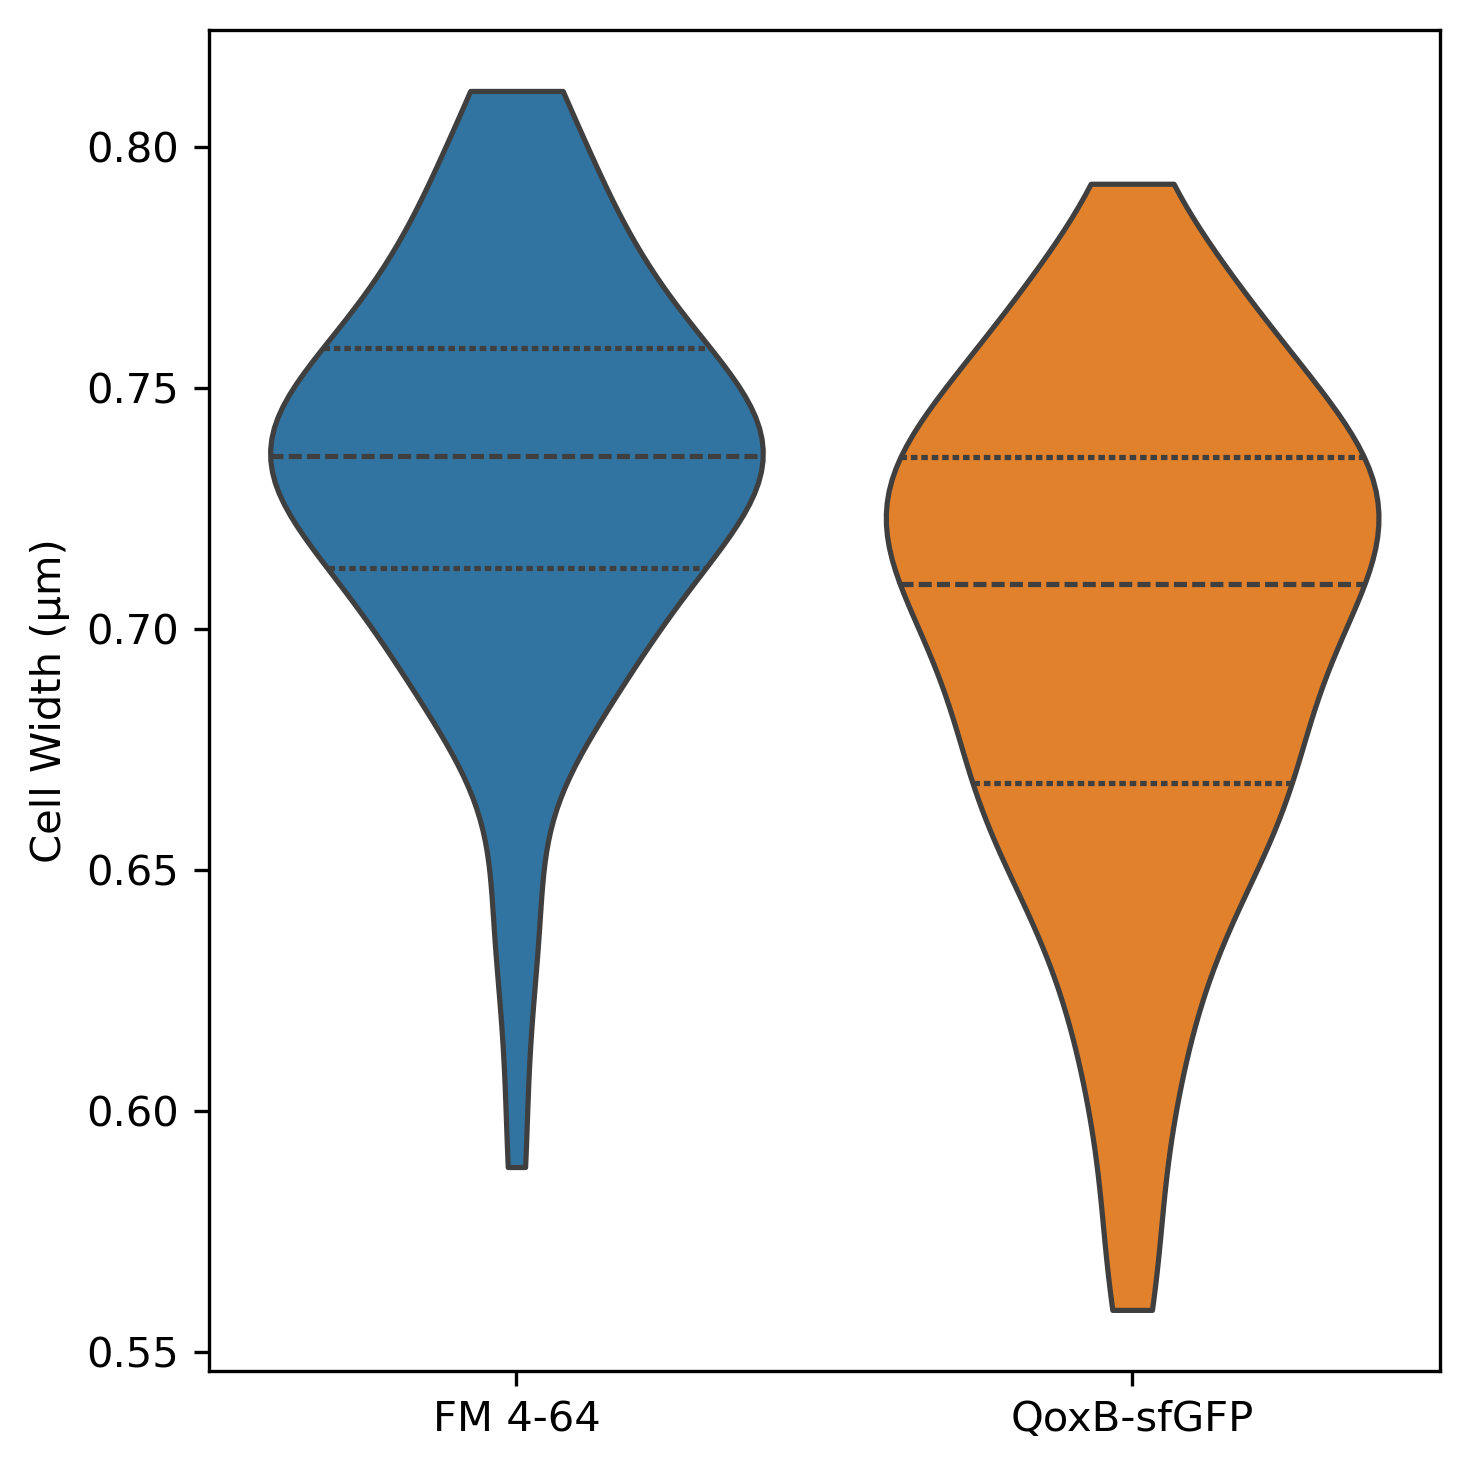

In [22]:
joint_df = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS12_violins.csv')
w = ConfIntSampler(joint_df,columns=['Target'],metric='Width')

fig,ax = plt.subplots(dpi=300,figsize=(5,5))

sns.violinplot(data=w,x='Target',y='Width',hue='Target',inner='quart',cut=0,ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Cell Width (µm)')

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig_FM_QoxB_size.png')

In [6]:
joint_df.drop(['Image_full_path','Image'],axis=1,inplace=True)

joint_df.groupby('Target').median()

,label,Width,Length,SurfaceArea,Volume
Target,,,,,
FM 4-64,8.0,0.735830,3.527735,6.869878,1.213241
QoxB-sfGFP,12.0,0.708946,3.456470,6.466053,1.067883
